#**Integración numérica**

## **Cálculo de trayectorias**

Las trayectorias se obtienen resolviendo la ecuación de un elemento de fluido en la descripción Lagrangiana:

$$ \frac{\text{d} \mathbf{X}}{\text{d} t} = \mathbf{u}\left(\mathbf{X}, t\right) \quad,\quad \mathbf{X}(0) = \mathbf{X}_0 $$

Esto es una Ecuación Diferencial Ordinaria (EDO) de dimensión $d$ igual a la dimensión espacial ($d=2$ o $d=3$ dependiendo del caso).
Obtener una solución analítica para el caso general no es posible, por lo que muchas veces debemos buscar una solución numérica.

Si queremos una solución aproximada para $\mathbf{X}(t)$ en el intervalo $t\in[t_0, t_0+T]$, discretizamos el tiempo $t$ en valores $t_j = t_0+j\Delta t$ y la solución $\mathbf{X}_j = \mathbf{X}(t_j)$ para $j=0,..,N$ con $N$ el número de pasos y $\Delta t=T/N$ el _paso temporal_.
Lo que necesitamos a continuación es un _esquema numérico_ que nos permita obtener $\mathbf{X}_{j+1}$ conociendo $\mathbf{X}_0, .., \mathbf{X}_j$.




### **Esquemas de Runge-Kutta**

Cuando uno conoce la dependencia funcional $\mathbf{u}(\mathbf{X}, t)$, es posible obtener una aproximación arbitrariamente buena para $\mathbf{X}_{j+1}$ usando solamente $\mathbf{X}_j$.
Hacemos esto mediante evaluaciones sucesivas de $\mathbf{u}$ en distintos valores asociados a $\mathbf{X}_j$.

El caso más simple es Runge-Kutta de orden 1 (RK1), que equivale al algoritmo de Euler:

$$ \mathbf{X}_{j+1} = \mathbf{X}_j + \mathbf{u}(\mathbf{X}_j, t_j)\Delta t $$

Esto equivale a evaluar la derivada de $\mathbf{X}(t)$ a tiempo $t_j$ y hacer una extrapolación lineal para obtener una estimación de $\mathbf{X}(t_{j+1})$.
Sin embargo, sabemos que $\mathbf{X}_{j+1}\neq \mathbf{X}(t_{j+1})$.

Consideremos el caso $d=1$ y que a tiempo $t_i$ estamos parados sobre una dada curva $X(t)$ con $X_i=X(t_i)$. Al aplicar el método de Euler, el nuevo valor $X_{i+1}$ no estará sobre $X(t)$, sino sobre otra curva solución $X'(t)$ tal que $X'(t_{i+1}) = X_{i+1}$.

![picture](https://drive.google.com/uc?export=view&id=1uJxuTPlQSgsthrdImwl0O4dxx78inRi5)

Para evitar desviarnos tanto, podemos de $X(t)$ en $t_i$ con la de $X'(t)$ en $t_{i+1}$ y geométricamente vemos que da una aproximación mejor

![picture](https://drive.google.com/uc?export=view&id=1SObM3o4sTNDr2ZowF9nkVoguA7C5-E8T)

Esto último arroja el método de Runge-Kutta de orden 2 (RK2), el particular el conocido cómo _punto medio_ o _midpoint_.

$$ \mathbf{X}_{j+1} = \mathbf{X}_j + \left[\mathbf{u}(\mathbf{X}_j, t_j) + \mathbf{u}\left(\mathbf{X}_j+\mathbf{u}(\mathbf{X}_j, t_j)\Delta t, t_j+\Delta t\right)\right] \frac{\Delta t}{2} $$


A continuación hay algunos métodos Runge-Kutta en una notación más general:

**Orden 1:**

$$\text{Euler:}\qquad \mathbf{X}_{j+1} = \mathbf{X}_j + \Delta t\mathbf{k}_1 \quad,\quad \mathbf{k}_1 = \mathbf{u}(\mathbf{X}_j, t_j)$$

**Orden 2:**

\begin{align*}
\text{Heun:}&\qquad \mathbf{X}_{j+1} = \mathbf{X}_j + \frac{\Delta t}{2}\left[\mathbf{k}_1+\mathbf{k}_2\right] \quad,\quad \mathbf{k}_1 = \mathbf{u}(\mathbf{X}_j, t_j),\quad \mathbf{k}_2 = \mathbf{u}\left(\mathbf{X}_j+\Delta t\mathbf{k}_1, t_j+\Delta t\right) \\
\text{Punto medio:}&\qquad \mathbf{X}_{j+1} = \mathbf{X}_j + \Delta t\mathbf{k}_2 \quad,\quad \mathbf{k}_1 = \mathbf{u}(\mathbf{X}_j, t_j),\quad \mathbf{k}_2 = \mathbf{u}\left(\mathbf{X}_j+\frac{\Delta t}{2}\mathbf{k}_1, t_j+\frac{\Delta t}{2}\right)
\end{align*}


**Orden 4:**

$$\text{RK4:}\qquad \mathbf{X}_{j+1} = \mathbf{X}_j + \frac{\Delta t}{6}\left[\mathbf{k}_1 + 2\mathbf{k}_2 + 2\mathbf{k}_3 + \mathbf{k}_4\right] $$
\begin{align*}
\mathbf{k}_1 = \mathbf{u}(\mathbf{X}_j, t_j) \qquad & \qquad
\mathbf{k}_2 = \mathbf{u}\left(\mathbf{X}_j+\frac{\Delta t}{2}\mathbf{k}_1, t_j+\frac{\Delta t}{2}\right) \\
\mathbf{k}_3 = \mathbf{u}\left(\mathbf{X}_j+\frac{\Delta t}{2}\mathbf{k}_2, t_j+\frac{\Delta t}{2}\right) \qquad & \qquad
\mathbf{k}_4 = \mathbf{u}\left(\mathbf{X}_j+\Delta t\mathbf{k}_3, t_j+\Delta t\right) \\
\end{align*}

### **Convergencia y adimensionalización**

Previamente mencionamos el _orden_ de un esquema, que nos dice el ritmo de convergencia de nuestra aproximación a la solución exacta a medida que reducimos $\Delta t$.
Un método tiene orden $n$ si el error que cometemos en cada paso es $\mathcal{O}(\Delta t^{n+1})$ y el error acumulado es $\mathcal{O}(\Delta t^n)$.
Vemos entonces que el error de RK4 decrece bastante más rápido que el de RK2, pero el costo computacional es mayor.
Que este costo extra se justifique depende de la complejidad del problema; para muchos problemas un esquema RK2 será suficiente.

Sin embargo, el orden es una buena estimación del error solo en el caso de $\Delta t$ suficientemente pequeño _respecto a alguna escala temporal característica del problema_.
Para ilustrar esto, consideremos un caso sin dependencia temporal explícita en 2D:
$$ \mathbf{u}(x,y, t) = U_0\left(\cos(ky)\hat{x} + \cos(kx)\hat{y}\right) $$

¿Cual es la escala temporal característica de este problema? El campo tiene dos _parámetros_ $U_0$ y $k$. El primero es una escala de velocidad y el segundo de distancia inversa; $[U_0]= m/s$ y $[k]=1/m$.
En principio no tenemos escala temporal, pero vemos que es posible construir una cómo $\tau = (kU_0)^{-1}$.
Por lo tanto, lo que buscamos es que $\Delta t \ll (kU_0)^{-1}$.

Otra forma de ver esto es notar que en $\mathbf{u}(x,y, t)$ las variables $x$ e $y$ aparecen _siempre_ acompañadas por un $k$, por lo que en algún sentido la variables naturales a considerar serían $x' = kx$ e $y' = ky$.
Con esto en mente podemos multiplicar a ambos lados por $k$ y reescribir la ecuación cómo
$$ \frac{\text{d}\mathbf{X}'}{dt} = kU_0\left(\cos(y')\hat{x} + \cos(x')\hat{y}\right) $$
y vemos que naturalmente aparece el tiempo característico $\tau = (kU_0)^{-1}$.
Despejando podemos obtener
$$ \frac{\text{d}\mathbf{X}'}{d(kU_0t)} = \cos(y')\hat{x} + \cos(x')\hat{y} $$
donde usamos que $kU_0$ es una constante y por lo tanto puede meterse dentro del diferencial.
Esto nos motiva a definir un tiempo $t'=kU_0t = t/\tau$, que, al igual que $\mathbf{X}'$, es _adimensional_.
Nuestro problema se reduce entonces a resolver una EDO _sin parámetros_
$$ \frac{\text{d}\mathbf{X}'}{dt'} = \cos(y')\hat{x} + \cos(x')\hat{y} $$
para obtener una $\mathbf{X}'(t')$ y podemos recuperar la solución al problema original mediante $k\mathbf{X}(t) = \mathbf{X}'(kU_0t)$.
Normalmente este último paso es innecesario y nos limitamos a computar $k\mathbf{X}$ en función de $kU_0t$, al ser un reescaleo trivial.

Es inmediato ver que la condición $\Delta t \ll (kU_0)^{-1}$ para la ecuación adimensionalizada traduce simplemente a $\Delta t' \ll 1$, que en algún sentido es mucho más claro.

### **Esqueleto de una integración de trayectoria**



In [22]:
import numpy as np
import matplotlib.pyplot as plt

def esquema(X, u, t, dt):
    """
    Calcula X(t+dt) a partir de X(t) y el campo de velocidades.

    Parámetros:
      X : Solución a tiempo t (X(t)) cómo arreglo de dimensión d
      u : Campo de velocidades cómo función de (x,t)
      t : Tiempo donde se conoce t
      dt: Paso temporal
    """
    # COMPLETAR
    return

def trayectoria(X0, u, N, dt):
    """
    Calcula numéricamente la solución a dX/ds = u(X,t) cómo
    un arreglo, usando el esquema definido previamente

    Parámetros:
      X0: Condición inicial cómo arreglo de dimensión d
      u : Campo de velocidades cómo función de (x,t)
      N : Número de pasos temporales
      dt: Paso temporal
    """
    d = X0.shape[0]            # Dimensión del problema
    ts = np.arange(0, N+1)*dt  # Tiempos donde calcularé la solución
    Xs = np.zeros((N+1, d))    # Solución aproximada
    Xs[0] = X0                 # Impongo la condición inicial a t=0
    for j in range(N):
        # Aplico esquema anterior sobre Xs[j] para obtener Xs[j+1]
        Xs[j+1] = esquema(Xs[j], u, ts[j], dt)
    return ts, Xs

## **Cálculo de líneas de corriente**

Para una línea de corriente, el tiempo $t$ está fijo (es un parámetro) y la integración se hace a lo largo de un parametrizador $s$

$$ \frac{\text{d} \mathbf{l}}{\text{d} s} = \mathbf{u}\left(\mathbf{l}(s), t\right) \quad,\quad \mathbf{l}\left(s=0\right) = \mathbf{l}_0 $$

Entonces, para cada par de parámetros $(\mathbf{l}_0,t)$ tendremos una línea de corriente diferente parametrizada por $s$.
Es posible reciclar mucho del esqueleto anterior, cambiando la variable de integración $t\to s$ y dejando $t$ cómo un parámetro.
Es importante notar que $\mathbf{u}$ no dependerá explícitamente de $s$, así que $s$ no se usa al aplicar el esquema numérico.

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def linea_de_corriente(l0, u, t, N, ds):
    """
    Calcula numéricamente la solución a dX/ds = u(X,t) cómo
    un arreglo, usando el esquema definido previamente

    Parámetros:
      l0: Origen de la línea cómo arreglo de dimensión d
      u : Campo de velocidades cómo función de (x,t)
      t : Tiempo para el cual se está calculando la línea
      N : Número de pasos en s
      ds: Paso del parametrizador
    """
    d = l0.shape[0]            # Dimensión del problema
    s = np.arange(0, N+1)*ds   # Valores del parametrizador s
    ls = np.zeros((N+1, d))    # Solución aproximada a lo largo de s
    ls[0] = l0                 # Impongo la condición inicial a s=0

    # Construyo una función que me genere la función u(x) a un tiempo
    # dado t y tome s cómo parámetro mudo (lo ignora)
    u_lc = lambda x, _: u(x, t)

    for j in range(N):
        # Aplico esquema sobre ls[j] para obtener ls[j+1]
        # El parámetro t es mudo (ver arriba u_lc)
        ls[j+1] = esquema(ls[j], u_lc, t, ds)
    return s, ls

###**Ejemplo**

Consideremos el flujo de la sección anterior
$$ \mathbf{u}(x,y, t) = U_0\left(\cos(ky)\hat{x} + \cos(kx)\hat{y}\right) $$
y calculemos sus trayectorias y líneas de corriente numéricamente para ver que coinciden.

Usaremos un esquema de Euler a modo ilustrativo, en general no es recomendable al ser poco preciso e inestable (no definimos este concepto, pero se imaginarán...). En la integración de trayectoria usamos un paso algo mayor y vemos rápidamente que las trayectorias no se cierran del todo.
Esto no ocurre para las líneas de campo, donde usamos un paso menor y, por lo tanto, acotamos el error.

Text(0.5, 1.0, 'Líneas de corriente | d$s=0.001$')

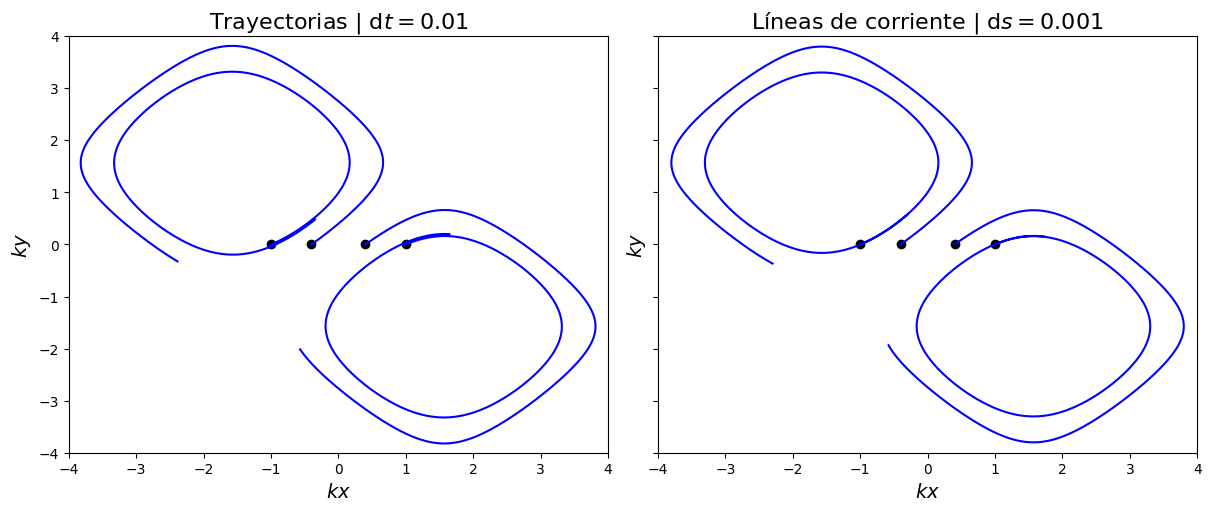

In [24]:
def esquema(X, u, t, dt):
  """
  Calcula X(t+dt) a partir de X(t) y el campo de velocidades,
  usando el esquema de Euler (MALO)

  Parámetros:
    X : Solución a tiempo t (X(t)) cómo arreglo de dimensión d
    u : Campo de velocidades cómo función de (x,t)
    t : Tiempo donde se conoce t
    dt: Paso temporal
  """
  return X + u(X,t)*dt

u = lambda X, t: np.array([np.cos(X[1]), np.cos(X[0])])
N = 1000
dt = 1e-2
p0s = np.array([[-1, 0], [1, 0], [-0.4, 0], [0.4, 0]])

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12,5), constrained_layout=True,
                               sharex=True, sharey=True)
for i in range(4):
  _, Xs = trayectoria(p0s[i], u, N, dt)
  ax1.plot(Xs[0,0], Xs[0,1], "ko")
  ax1.plot(Xs[:,0], Xs[:,1], "b-")

N = 10000
ds = 1e-3
for i in range(4):
  _, ls = linea_de_corriente(p0s[i], u, 0, N, ds)
  ax2.plot(ls[0,0], ls[0,1], "ko")
  ax2.plot(ls[:,0], ls[:,1], "b-")

ax1.set_xlim(-4,4)
ax1.set_ylim(-4,4)
ax1.set_xlabel('$kx$', fontsize=14)
ax1.set_ylabel('$ky$', fontsize=14)
ax1.set_title(f'Trayectorias | d$t={dt}$', fontsize=16)
ax2.set_xlabel('$kx$', fontsize=14)
ax2.set_ylabel('$ky$', fontsize=14)
ax2.set_title(f'Líneas de corriente | d$s={ds}$', fontsize=16)

### **Elección de condiciones iniciales**

En muchos problemas de Física, las condiciones iniciales vienen dadas por el problema. Para el caso de representaciones, queda en nuestras manos elegir las más apropiadas.
En este contexto, más apropiado es que provea mayor información: que las curvas llenen lo más posible el espacio sin saturarlo y volverlo confuso.

Para esto, necesitamos mirar previamente el campo de velocidad y generarnos una idea cualitativa de cómo sería la dinámica. En el ejemplo anterior, vemos que el campo es sinusoidal, así que podríamos esperar trayectorias periódicas y, por lo tanto, curvas cerradas. Además, el campo es cartesiano, así que ubicar puntos a lo largo rectas paralelas a los ejes $x$ e $y$ es razonable.

Si todo falla, prueba y error es siempre un enfoque posible, teniendo en cuenta el objetivo de nuestra visualización.

## **Funciones para visualización**

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

def evolucionar_lineas(l0s, ts, u, N, ds, ext=None, figsize=None):
  """
  Calcula numéricamente las líneas de campo y las grafica en
  un video a medida que avanza el tiempo. Asume que existe
  una funcion 'linea_de_corriente' previamente definida.

  Parámetros:
    l0s: Origen de las líneas cómo arreglo de dimensión (n,2)
    u  : Campo de velocidades cómo función de (x,t)
    ts : Tiempos para los cuales se calculan las líneas cómo
         arreglo de dimensión m
    N  : Número de pasos en s
    ds : Paso del parametrizador
    ext: Límites espaciales del grafico [xmin,xmax,ymin,ymax]
figsize: Tamaño de la figura
  """
  n = l0s.shape[0]   # Cantidad de líneas de corriente
  m = ts.shape[0]    # Cantidad de tiempos (fotogramas)
  ls = np.zeros((m, n, N+1, 2))
  for i in range(m):
    for j in range(n):
      _, ls[i,j] = linea_de_corriente(l0s[j], u, ts[i], N, ds)
  xs = ls[:,:,:,0]
  ys = ls[:,:,:,1]

  if ext is None:
    extent = [np.min(np.array(xs)), np.max(np.array(xs)),
              np.min(np.array(ys)), np.max(np.array(ys))]
  else:
    extent = ext

  # Guardo el estado de plt
  params_viejos = plt.rcParams
  plt.rc('animation', html='jshtml')

  fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
  plt.close();  # Cerrar la figura, animation va a crear la suya propia

  # Inicializo las curvas
  plots = [ ax.plot([], [], "b-")[0] for i in range(n) ]
  dots  = [ ax.plot([], [], "ko")[0] for i in range(n) ]
  ax.set_title("$t=0$")
  ax.set_xlabel("x")
  ax.set_ylabel("y")

  def init():
    """ Inicializador de la figura y gráfico de condiciones iniciales."""
    sup = 0
    for i, (x, y) in enumerate(zip(xs[0], ys[0])):
      dots[i].set_xdata([x[0]])
      dots[i].set_ydata([y[0]])
      sup = max(sup, max(np.max(np.abs(x)), np.max(np.abs(y))))

    ax.set_aspect('equal')
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])

    return plots

  def actualizar(t):
    """ Actualiza los datos al fotograma actual."""
    print(f"\rCalculando fotograma {t} de {m}",
          end="")

    for i, (x, y) in enumerate(zip(xs[t], ys[t])):
      plots[i].set_xdata(x)
      plots[i].set_ydata(y)

    ax.set_title(f"$t={ts[t]:.5f}$")

    return plots

  anim = animation.FuncAnimation(fig, actualizar, init_func=init,
                                 frames=range(0, m), blit=True, repeat=True)

  # Restauro el estado de plt
  plt.rc(params_viejos)

  return anim

## **Ejemplo: Flujo uniforme con variación temporal**

Consideremos el flujo dado por
$$ \mathbf{u}(\mathbf{x}, t) = U\left( \hat{x} + \frac{t}{\tau}\hat{y} \right)$$

Para este problema la adimensionalización es trivial, definimos $t' = t/\tau$ y $\mathbf{u}'=\mathbf{u}/U$.
Habiendo definido unidades de tiempo ($\tau$) y velocidad ($U$), la unidad de distancia es simplemente $U\tau$, tal que $\mathbf{x}' = \mathbf{x}/U\tau$.
El flujo adimensionalizado finalmentecarece de parámetros

$$ \mathbf{u}'(\mathbf{x}', t) = \hat{x} + t'\hat{y} $$



(-1.0, 1.0)

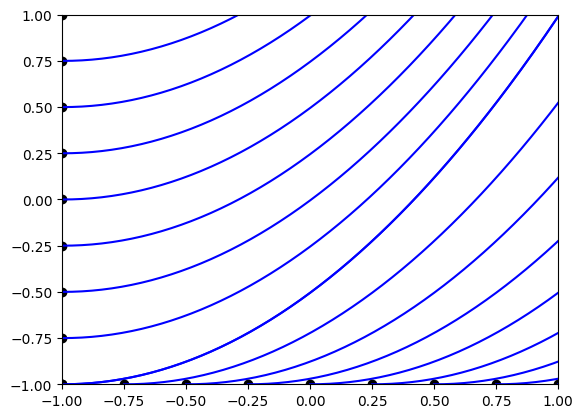

In [26]:
def u(X,t):
  return np.array([1, t])

N = 200
ds = 1e-2
l0s = [[-1, a] for a in np.linspace(-1, 1, 9)]
l0s = l0s + [[a, -1] for a in np.linspace(-1, 1, 9)]
l0s = np.array(l0s)
for i in range(l0s.shape[0]):
  t, Xs = trayectoria(l0s[i], u, 200, 1e-2)
  plt.plot(Xs[0,0], Xs[0,1], "ko")
  plt.plot(Xs[:,0], Xs[:,1], "b-")
plt.xlim(-1, 1)
plt.ylim(-1, 1)

In [27]:
ts = np.linspace(0, 2, 21)
evolucionar_lineas(l0s, ts, u, N, ds, ext=[-1,1,-1,1], figsize=None)

Calculando fotograma 20 de 21

##**Integración de EDOs de mayor orden**

Si la ecuación diferencial involucra derivadas de orden mayor a 1, la solución es aumentar la dimensión de nuestro problema agregando variables con ecuaciones triviales.
Por ejemplo, para el oscilador armónico 1D
$$ \ddot{x} = -\omega^2 x$$
construimos un vector $\mathbf{X} = (x_1, x_2)$ donde $x_1=x$ y $x_2=\dot{x}$.
La ecuación para $\dot{x}_2 = \ddot{x}$ es la original, pero para $x_1$ debemos agregar la ecuación trivial $\dot{x}_1=x_2$.
Por lo tanto, nos queda una EDO 2D de la forma
$$ (\dot{x}_1, \dot{x}_2) = \dot{\mathbf{X}} = \mathbf{F}(\mathbf{X}, t) = (x_2, -\omega^2 x_1) $$

Cómo vemos debimos aumentar la dimensión de nuestra solución a cambio de bajar el orden de nuestras derivadas a 1 nuevamente.

#**PINNs**

Las **redes neuronales informadas por la física** (PINN, por sus siglas en inglés) son aproximadores de funciones que incorporan el conocimiento de las leyes físicas que rigen un sistema durante el proceso de aprendizaje. El trabajo fundacional sobre este enfoque es: [Raissi, M., P. Perdikaris, and G. E. Karniadakis. “Physics-Informed Neural Networks: A Deep Learning Framework for Solving Forward and Inverse Problems Involving Nonlinear Partial Differential Equations.” Journal of Computational Physics 378 (February 1, 2019): 686–707.](https://doi.org/10.1016/j.jcp.2018.10.045)

Una PINN es, esencialmente, una **red neuronal artificial**. Las redes neuronales (artificiales) se inspiran en la forma en que funcionan las redes de neuronas en los sistemas biológicos, aunque son modelos matemáticos mucho más simples.

De forma simplificada, una red neuronal puede pensarse como una **función** con muchos **parámetros** que toma un *input* (X) y produce un *output* (Y). Generalmente está compuesta por varias **capas ocultas**, cada una con un cierto número de neuronas (marcadas en amarillo en la figura de abajo). Cada neurona de una capa está conectada con las neuronas de la capa siguiente, de forma que la información fluye en una sola dirección desde el *input*. Este tipo de red se lo conoce como *feedforward* . A cada una de esas conexiones se le asigna un **parámetro o peso**, cuyo valor debe determinarse durante el proceso de entrenamiento de la red.





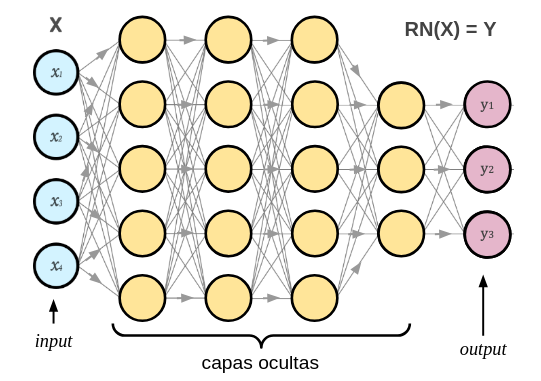

##**La Neurona**






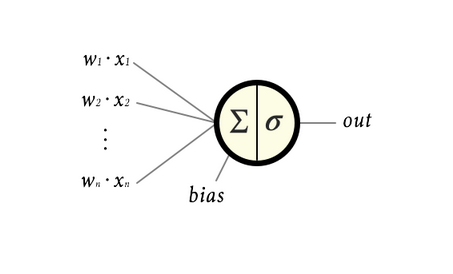

Antes de explicar la red veamos cómo funciona una simple neurona. El *input* de cada neurona está pesada  por el *output* de todas las neuronas en la capa anterior
$$ z = \sum_{i=0}^n w_i x_i$$

La señal de _input_ que recibe una neurona se combina primero de forma lineal con los pesos (_weights_, en inglés) de las conexiones. Luego, el resultado se transforma mediante una **función de activación**. Esta función determina qué **tan relevante es la neurona** para producir el resultado final de la red. Algunas saturan en 1 si $z$ es positivo y anulan la neurona si la $z$ es negativo, como la función **sigmoide**. Otras también anulan la neurona si el arguento es negativo pero si $z$ es positivo el peso del output crece con $z$,  como la función **ReLU**. En la figura se muestran algunos ejemplos de funciones de activación típicas.

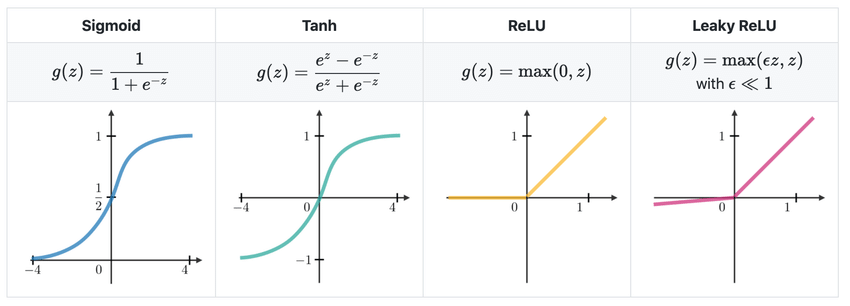

Lo más importante es que la función de activación ($\sigma$) introduce **no linealidad** en la red. Sin esta no linealidad, la red sería simplemente una composición de transformaciones lineales y no podría representar relaciones complejas entre las variables.

Por último, debemos mencionar el **bias** de la neurona. Este es otro parámetro que la red puede ajustar durante el entrenamiento. El bias se suma a la combinación lineal de las neuronas de la capa anterior antes de aplicar la función de activación. Su función es desplazar el valor de entrada de la función de activación. Es decir, impone un valor que debe alcanzar la suma para que la neurona se active.

Con esta información ya podemos escribir que el  *output* de la  neurona $j$ en una capa interna es:

$$ O_j = \sigma \left(\sum_{i=0}^n w_{ij} x_i + b_j\right)$$


## **Red con Una Capa Oculta**




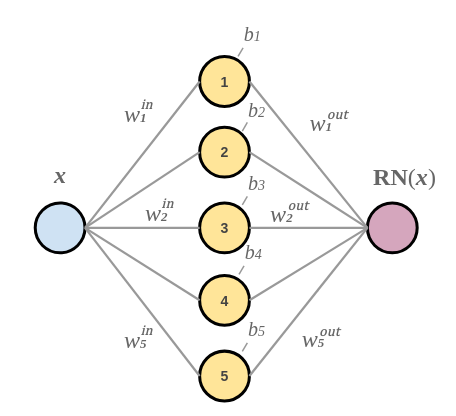

Veamos un caso sencillo para entender por qué una red neuronal puede aproximar funciones. En la figura  se muestra una red simple con una dimensión de input, una capa oculta con varias neuronas y una dimensión de output. Una red de este tipo puede utilizarse para modelar una función $f(x)$.


Hagamos el ejercicio en el codigo de abajo y veamos que podemos aproximar $f(x) = x^3 - 3 x^2 + 2x +5$, en el rango $2< x< 4$, con cinco neuronas en la capa oculta. Supongamos que cada neurona es una función  ReLu. Cuando enviamos un *input* $x$ a la red, cada neurona de la capa oculta recibe el valor multiplicado por un peso, $w^{in}_j$, sumado a un bias, $b_j$. Al resulatdo se le aplica la función de activación  y la salida se obtiene sumando todas las contribuciones de los *outputs* de cada neurona, $O_j$, por los los pesos de salida, $w^{out}_j$,  

$$out =\sum_{j=1}^5w^{out}_j O_j = \sum_{j=1}^5 w^{out}_j \,  \sigma(w^{in}_j  x + b_j)   $$



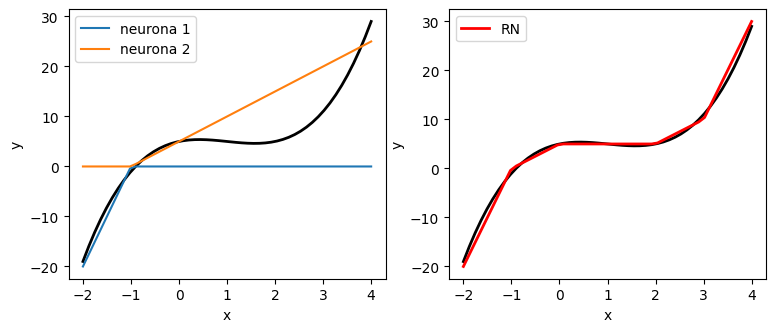

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# Funcion ReLu
def ReLu(x):
  return np.maximum(0, x)

# Funcion que quiero aproximar
def f(x):
  return  x**3 - 3*x**2 + 2*x + 5

# Defino parametros de la red
w1, w2, w3, w4, w5 = -1, 1, 1, 1, 1    # Pesos hacia la capa oculta (w^in)
b1, b2, b3, b4, b5 = -1, 1, 0, -2, -3  # Bias de la capa oculta
s1, s2, s3, s4, s5 = -20, 5, -5, 5, 15 # Pesos hacia la salida (w^out)

# Red neuronal
def RN(x):
  return s1*ReLu(w1*x + b1) + s2*ReLu(w2*x + b2) + s3*ReLu(w3*x + b3) + s4*ReLu(w4*x + b4) + s5*ReLu(w5*x + b5)

# Grafico
x = np.linspace(-2, 4, 50)
fig, axs = plt.subplots(1, 2, figsize = (9, 3.5))
ax = axs[0]
ax.plot(x, f(x), color = 'k', linewidth = 2)
ax.plot(x, s1*ReLu(w1*x + b1), label = 'neurona 1')
ax.plot(x, s2*ReLu(w2*x + b2), label = 'neurona 2')
ax.set_xlabel('x'), ax.set_ylabel('y')
ax.legend()
ax = axs[1]
ax.plot(x, f(x), color = 'k', linewidth = 2)
ax.plot(x, RN(x), color = 'r', linewidth = 2, label = 'RN')
ax.set_xlabel('x'), ax.set_ylabel('y')
ax.legend()


Entonces, vimos que pudimos aproximar un polinomio   por funciones ReLu. Cosas similares ya nos hemos encontrado, desde el principio de la carrera se nos muestra serie de Fourier.  Lo que nos permite geralizar esta idea es el **Teorema de Aproximación Universal**. Este nos asegura que cualquier red neronal aproxima cualquier función:

*Una red neuronal feedforward, con una de sus capas ocultas definida por un número finito de neuronas, puede aproximar cualquier función continua en un rango finito de input, con cualquier grado de presición, si la función de activación no es lineal, es acotada y es continua.*

Entonces podría parecer que una red con una sola capa oculta es suficiente. **¿Por qué se utilizan redes con muchas capas?** Porque, cuando el problema se vuelve más complejo, resulta más eficiente que cada capa aprenda representaciones intermedias más simples, permitiendo que la red reconozca patrones de manera progresiva. De esta forma, en lugar de resolver todo de una vez, la red descompone el problema en varios pasos. Es posible visualizar este proceso en [Tensor Flow Playground](https://playground.tensorflow.org/#activation=relu&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=3,1&seed=0.49404&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false).

La cantidad de capas y de neuronas en cada una depende de la tarea que se quiera realizar. A esta elección se la conoce como arquitectura de la red. En este apunte no nos enfocaremos demasiado en este aspecto, sino que utilizaremos arquitecturas simples adaptadas al problema que queremos resolver.

##**Función de costo, Descenso por el Gradiente y _Backpropagation_**

Ya  vimos que podemos aproximar cualquier función  $\mathbf{f}:\mathbb{R}^n \rightarrow \mathbb{R}^m$ por una red neuronal  $\mathbf{RN}:\mathbb{R}^n \rightarrow \mathbb{R}^m$. Ahora nos falta saber cómo encontrar los parámetros porque no es una tarea que deseemos hacer a mano. Como vimos recientemente, una red neuronal *feedforward* es una función, donde el  *output* de cada capa inerna $\ell$ es una función de la capa anterior
$$ \mathbf{O}^{\ell} = \sigma\left( \mathbf{W}^{\ell}\mathbf{O}^{\ell-1} + \mathbf{b}^{\ell}\right)$$
pero a fin de cuentas, la red es la composición de las múltiples funciones
$$ \mathbf{RN}(\mathbf{x}) = \mathbf{W}^{out}\, \mathbf{O^{N}} + \mathbf{b}^{out} = \mathbf{W}^{out} \, \sigma\left(\mathbf{W^{N}} \mathbf{O}^{N-1} + \mathbf{b}^{N}\right) + \mathbf{b}^{out}  = ... $$
donde $N$ es el número de capas internas.

Para determinar los parámetros de la red utilizaremos ideas básicas de optimización ¿Cómo sabemos si la red aproxima bien la función que queremos? Para responder esto definimos un **error (o función de costo)** que cuantifique la diferencia entre la función  objetivo y la salida de la red. En el tipo de entrenamiento que utilizaremos es necesario conocer el valor de la función en algunos puntos. Este enfoque se conoce como *supervised learning*.

Supongamos que conocemos el valor de la función $\mathbf{f}$ en un conjunto de puntos \{ ($\mathbf{x}^d_i,\, \mathbf{f}(\mathbf{x}^d_i)) \, ; \, i = 1,.., N_d\}$. Entonces podemos estimar el error que comete la red para un conjunto de pesos y biases (que englomeramos en la variable $\mathbf{W}$) mediante

$$E = \frac{1}{N_d}\sum_{i = 1}^{N_d}|\mathbf{f}(\mathbf{x}^d_i) - \mathbf{RN}(\mathbf{x}^d_i, \mathbf{W})|^2$$

Este se lo conoce como **error cuadrático medio (MSE)**. No es la única manera de cuantificar el error pero es de las más usuales. Nuestro objetivo es **minimizar este error**. Notemos que el error depende de los pesos de la red. y  recordemos del análisis matemático que el gradiente de una función indica la dirección de máximo crecimiento. Como queremos reducir el error, debemos movernos en la dirección opuesta al gradiente

$$\mathbf{W}_{\text{nuevo}} = \mathbf{W} - \eta \nabla_{\mathbf{w}}E$$

A esto se lo conoce como **descenso por el gradiente**, donde $\eta$ es  **_learning rate_**. Cuando la red ha procesado todos los datos de entrenamiento una vez completa y actualiza $\mathbf{W}$, se dice que se ha completado una **_epoch_**. La idea es repetir este proceso varias veces hasta que la red aproxime la función al punto que considere suficiente.

**Backpropagation** básicamente es optimizar descenso por el gradiente  aprovechando propiedades de las funciones de activación y regla de la cadena, propagando la información del error desde el *output* hacia las capas anteriores.

En las redes informadas por la física (**PINNs**) el error que se minimiza no solo mide qué tan bien la red ajusta los datos, además cuantifica que tan bien se cumplen las leyes físicas que gobiernan el sistema.
El término físico se construye evaluando la ecuación diferencial que debería satisfacer la solución. Por ejemplo, si el problema que queremos resolver está gobernado por la siguiente ecuación:

$$\frac{\mathrm{d} \mathbf{X}}{\mathrm{d} t} =  \mathbf{u}(\mathbf{X}, t) $$

el error de los datos y de la física es:

$$\text{MSE}_d =\frac{1}{N_d} \sum_{i = 1}^{N_d} \left|\mathbf{X}(t^d_i) - \mathbf{RN}(t^d_i,  \mathbf{W}) \right|^2$$

$$  \text{MSE}_f = \frac{1}{N_f} \sum_{j = 1}^{N_f} \left|\frac{\partial \mathbf{RN}}{\partial t}\left(t^f_j, \mathbf{W}\right) -  \mathbf{u}\left(\mathbf{RN}(t^f_j,\mathbf{W}), t^f_j\right)\right|² $$

El error de la fisica es reescribir la ecuación diferencial igualada a cero. Si la red neuronal cumple la física, el error es cero.  La función de costo es la suma de ambos con el error de la física pesado por un $\lambda$

$$ E = \text{MSE}_d + \lambda \text{MSE}_f$$

Ya todo lo que respecta al armado con la red y los errores es conveniente obrarlo con nuestras propias manos. En la siguiente sección veremos lo más importante, la implemenración y trabajo con redes neuronales.   

###**Referencias**

1. [Machine Learning Course, Tobias Hill](https://machinelearning.tobiashill.se/2018/12/04/part-2-gradient-descent-and-backpropagation/)

2. [Build Neural Network, Pytorch](https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html)

3. [Material de Sistemas Dinámicos Aplicado al Modelado de Datos, Gabriel Mildin.](https://asignaturas.df.uba.ar/sdeiaaamdd-mindlin/teoricas/)


#**Construcción de la red**


Para trabajar con redes neuronales hay librerías en Python especializadas, como *Pytorch*, *TensorFlow* y  *scikit-learn*.

Antes de comenzar, importamos las librerías que vamos a utilizar y definimos una clase que implementa un perceptrón multicapa (MLP), es decir, la red neuronal que emplearemos. El método ```__init__``` se encarga de construir la arquitectura de la red a partir de la lista ```sizes```. Los elementos de esta lista indican la cantidad de neuronas en cada capa: el primer elemento corresponde a la dimensión de entrada, los intermedios a las capas ocultas y el último a la capa de salida.


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.autograd import Variable
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

class MLP(torch.nn.Module):
    """
    Multilayer perceptron (MLP) // Perceptrón Multicapa .

    Args:
        sizes (lista): Lista de enteros que especifica el número de neuronas en
        cada capa.

    Atributos:
        capas (torch.nn.ModuleList): Lista que contiene las capas lineales del MLP.

    Métodos:
        forward(x): Realiza una pasada hacia adelante a través de la red MLP.

    Ejemplo:
        tamaños = [entrada_dim, oculta1_dim, oculta2_dim, salida_dim]
        mlp = MLP(tamaños)
        tensor_entrada = torch.tensor([...])
        salida = mlp(tensor_entrada)
    """

    def __init__(self,sizes):
        super().__init__()
        self.layers = torch.nn.ModuleList()
        for i in range(len(sizes)-1):
            self.layers.append(torch.nn.Linear(sizes[i],sizes[i+1]))

    def forward(self,x):
        h = x
        for hidden in self.layers[:-1]:
            h = torch.tanh(hidden(h))
        output = self.layers[-1]
        y = output(h)
        return y

##**Ejemplo**

Veamos qué pasa si tenemos un   campo  rotacional con una pequeña peturbación no lineal
$$\mathbf{u}(x, y) = \frac{U_0}{L} y \,  \hat{x} + \frac{U_0}{L} \left( -x + k x^3\right)\,  \hat{y}$$

Antes de entrenar la red, generamos los datos de entrenamiento. Para ello implementamos las herramientas vistas previamente en este apunte y resolvemos la ecuación utilizando el método de Runge–Kutta, con $U_0/L = 1$ y $k = 1.4$. A partir de la solución obtenida, subseleccionamos algunos puntos que utilizaremos para el entrenamiento y los organizamos en tensores, que son las estructuras de datos con las que trabaja PyTorch: cada fila representa una muestra del dataset y cada columna una variable.

In [ ]:
# Solucion con  RK

x0 = np.array([0.2, 0.5])
dt = 5e-4
tf = 8

pasos = int(tf/dt)
# t_sol, x_sol = #Desarrolle
# Parámetros del problema (los mismos que se usan en el ejemplo del notebook)
U0 = 1.0
k_true = 1.0 
k = k_true        # Este es el valor "verdadero" que queremos estimar con la PINN
T = 8.0               # Tiempo final de integración
N = 1000              # Número de pasos (puedes aumentar para mayor precisión)

# Campo de velocidades u(X) = [U0*cos(k*y), U0*cos(k*x)]
def u(X, t=None):
    x, y = X[0], X[1]
    ux = U0 * np.cos(k_true * y)
    uy = U0 * np.cos(k_true * x)
    return np.array([ux, uy])

# Esquema RK4 (como se explicó al principio del notebook)
def rk4_step(X, t, dt):
    k1 = u(X, t)
    k2 = u(X + 0.5*dt*k1, t + 0.5*dt)
    k3 = u(X + 0.5*dt*k2, t + 0.5*dt)
    k4 = u(X + dt*k3, t + dt)
    return X + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)

# Condición inicial
X0 = np.array([0.0, 0.0])          # Puedes cambiarla si quieres

# Integración
ts = np.linspace(0, T, N+1)
Xs = np.zeros((N+1, 2))
Xs[0] = X0

for j in range(N):
    dt = ts[j+1] - ts[j]
    Xs[j+1] = rk4_step(Xs[j], ts[j], dt)

# Resultado final
t_sol = ts
x_sol = Xs
# Subseleccionamos 10 datos para el entrenamiento
skip = pasos//10
t_data = torch.asarray([t_sol[i] for i in range(0, len(t_sol), skip)], dtype=torch.float32).view(-1,1)
x_data = torch.asarray([x_sol[i] for i in range(0, len(x_sol), skip)], dtype=torch.float32).view(-1,2)

##
Ahora definamos y entrenemos la red neuronal



In [46]:
# Ecuacion diferencial
def u(x, t):
    u1 = x[:,1]
    u2 = -x[:,0] + k * x[:,0]**3
    return torch.stack((u1, u2), dim=1)

#Definimos la red
pinn = MLP([1, 32, 32, 32, 2])
#Implementamos un optimizador
optimizer = torch.optim.Adam(pinn.parameters(), lr=5e-4)

iterations = 1500 #Epochs
l = 1e-4   # Lambda

#Definimos 20 tiempos de fisica
t_physics = torch.linspace(0, tf, 20).view(-1,1).requires_grad_(True)

loss_array = np.zeros(iterations) #Para guardar la funcion de costo
for epoch in range(iterations):
    optimizer.zero_grad() #Borra gradientes de la iteracion anterior

    # MSEd
    xhd = pinn(t_data)
    MSDd = torch.mean((xhd - x_data)**2)

    # MSEf
    xhf = pinn(t_physics)
    dx_dt   = torch.autograd.grad(xhf, t_physics, torch.ones_like(xhf), create_graph=True)[0] # Computamos dx/dt
    physics = dx_dt - u(xhf, t_physics)  # Ecuación diferencial
    MSDf = torch.mean(physics**2)        # Calculo el error cuadrático medio para la física

    # Ajustamos los pesos de la red
    loss = MSDd + l * MSDf
    loss.backward() #Calcula nuevos gradientes con backpropagation
    optimizer.step() #Actualiza los parámetros
    loss_array[epoch] = loss

    # Imprimimos la funcion de costo
    if epoch % 1000 == 0:
        with torch.autograd.no_grad():
            print(epoch, MSDd, l*MSDf, "Traning Loss:", loss.data)

0 tensor(0.0560, grad_fn=<MeanBackward0>) tensor(2.6359e-06) Traning Loss: tensor(0.0560)
1000 tensor(1.3496e-14, grad_fn=<MeanBackward0>) tensor(2.3222e-09) Traning Loss: tensor(2.3222e-09)


(np.float64(-0.0829495537405025),
 np.float64(1.6488432547073593),
 np.float64(-0.08668997020769229),
 np.float64(1.6490213697772254))

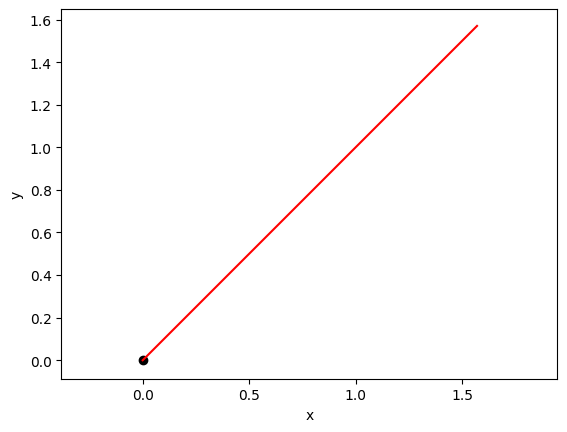

In [47]:
# Datos de prueba
Xd = x_data.detach().numpy()

# Prediccion de la red
t_pred = torch.linspace(0, 8, 200).view(-1,1)
X_pred = pinn(t_pred)
Xp = X_pred.detach().numpy()

# Grafico
plt.plot(Xp[:,0], Xp[:, 1])
plt.plot(Xd[:,0], Xd[:, 1], "ko")
plt.plot(x_sol[:,0], x_sol[:, 1], "r-")
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')


##**Función de costo: overfitting y underfitting**


¿Qué criterios podemos usar para evaluar si la red modela adecuadamente el problema? Una primera herramienta es analizar la convergencia de la función de costo durante el entrenamiento.

Puede ocurrir que la red neuronal sea demasiado simple para reproducir la complejidad del sistema. En ese caso se produce *underfitting*, y la función de costo no logra converger a valores pequeños. Una forma de mejorar el modelo es aumentar su capacidad, por ejemplo agregando más capas ocultas o más neuronas por capa. Sin embargo, al incrementar demasiado la complejidad del modelo aparece el riesgo de *overfitting*: la red se ajusta excesivamente a los datos de entrenamiento y pierde capacidad de generalización.  Para detectar este problema, es habitual evaluar la función de costo también sobre un conjunto de datos de prueba (o _test_). Si el error en entrenamiento es pequeño pero el error en los datos de prueba es grande, esto indica que el modelo está sobreajustado.





MSDd training:  tensor(3.4694e-15, grad_fn=<MeanBackward0>)
MSDd test:  tensor(1.9361, grad_fn=<MeanBackward0>)


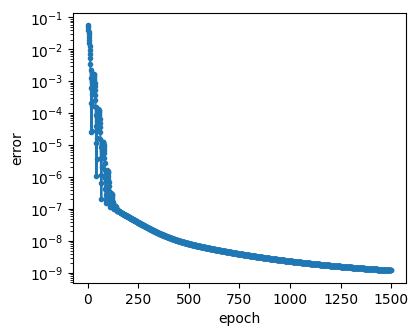

In [49]:
# Evolución de función de costo
plt.figure(figsize = (4.3, 3.5))
plt.plot(np.arange(iterations), loss_array, '.-')
plt.yscale('log')
plt.xlabel('epoch')
plt.ylabel('error')


# Test
t_test, x_test = torch.asarray(t_sol, dtype=torch.float32).view(-1, 1), torch.asarray(x_sol, dtype=torch.float32).view(-1, 2)

xh = pinn(t_data)
MSDd_training = torch.mean((xh - x_data)**2)
xh = pinn(t_test)
MSDd_test  = torch.mean((xh - x_test)**2)

print('MSDd training: ', MSDd_training)
print('MSDd test: ', MSDd_test)

##**Estimación de parámetros**

De la misma forma en la que se utilizan las redes neuronales informadas por la física como integradores también pueden utilizarse para estimar parametros de mediciones dado un modelo conocido del sistema.

Para eso, lo único que hay que hacer diferente respecto a lo que ya trabajamos (donde los parámetros eran una cuestión conocida) es dejar a estos como entrenables para inferirlos posteriormente a partir de los datos.

Escriba una red y entrenela para inferir el parametro no lineal $k$. Esta versión del perceptrón multicapa es igual a la que ya se utilizó anteriormente pero posee un parametro para el coeficiente que acompaña al término no lineal.  

In [50]:
class MLP(torch.nn.Module):
    """
    Multilayer perceptron (MLP) // Perceptrón Multicapa.

    Args:
        sizes (lista): Lista de enteros que especifica el número de neuronas en
        cada capa.

    Atributos:
        -capas (torch.nn.ModuleList): Lista que contiene las capas lineales del MLP.
        -k (torch.nn.Parameter): Parámetro entrenable que representa el coeficiente que acompaña la no linearidad del campo.

    Métodos:
        forward(x): Realiza una pasada hacia adelante a través de la red MLP.

    Ejemplo:
        tamaños = [entrada_dim, oculta1_dim, oculta2_dim, salida_dim]
        mlp = MLP(tamaños)
        tensor_entrada = torch.tensor([...])
        salida = mlp(tensor_entrada)
    """
    def __init__(self,sizes):
        super().__init__()
        self.layers = torch.nn.ModuleList()
        self.k = torch.nn.Parameter(data=torch.Tensor([1]), requires_grad=True)
        for i in range(len(sizes)-1):
            self.layers.append(torch.nn.Linear(sizes[i],sizes[i+1]))

    def forward(self,x):
        h = x
        for hidden in self.layers[:-1]:
            h = torch.tanh(hidden(h))
        output = self.layers[-1]
        y = output(h)
        return y


Además, al escribir el error asociado a la física deberá escribirla a partir de las derivadas de la red, `pinn.k`.